<a href="https://colab.research.google.com/github/allia-wase/Malaria_Diagnosis/blob/main/Malaria_Baseline_CNN_Hasbiyallah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


''

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-07 11:13:37--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.170.19.86, 3.170.19.87, 3.170.19.33, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.170.19.86|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   227MB/s    in 1.5s    

2026-06-07 11:13:39 (227 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


### Hasbiyallah Umutoniwabo — Baseline CNN
**Model:** Baseline CNN (Model 1 of 5)

This CNN serves as the **reference point** for the group.
All other models (improved CNN, VGG16, ResNet, MobileNet) will be compared against this.

This 2-block architecture follows the shallow CNN design used by Rajaraman et al. (2018), who showed simple CNNs are effective for cell-level malaria detection.

#### Architecture
| Layer | What it does |
|---|---|
| Conv2D (32 filters) | Scans image looking for edges and colours |
| MaxPooling2D | Shrinks image by half, keeps strongest signals |
| Conv2D (64 filters) | Detects more complex shapes and textures |
| MaxPooling2D | Shrinks again |
| Flatten | Converts 2D feature map → 1D list of numbers |
| Dense (64 neurons) | Combines features to make a decision |
| Dropout (0.5) | Randomly turns off neurons to prevent memorisation |
| Dense (1, sigmoid) | Outputs probability of infection (0 = healthy, 1 = infected) |

**Why sigmoid?** We have 2 classes, sigmoid gives one probability output between 0 and 1.

**Why ReLU?** It blocks negative values and keeps positives, helping the model learn patterns.

In [6]:
# ── Extra imports needed for evaluation ──
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import optimizers
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

# ── Settings ───
IMG_SIZE    = 64      # all images resized to 64x64
BATCH_SIZE  = 32
EPOCHS      = 15
CLASS_NAMES = ['Uninfected', 'Parasitized']

print("Setup complete ✓")

Setup complete ✓


In [7]:
# ── Load images from the cell_images folder the notebook already downloaded ──
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize pixel values to 0-1
datagen = ImageDataGenerator(
    rescale=1./255,          # divide pixels by 255
    validation_split=0.2     # use 20% for validation
)

# Training set (80%)
train_gen = datagen.flow_from_directory(
    'cell_images',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',     # infected or not
    subset='training',
    seed=42
)

# Validation/test set (20%)
val_gen = datagen.flow_from_directory(
    'cell_images',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print(f"Training images   : {train_gen.samples:,}")
print(f"Validation images : {val_gen.samples:,}")
print(f"Classes           : {train_gen.class_indices}")

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Training images   : 22,048
Validation images : 5,510
Classes           : {'Parasitized': 0, 'Uninfected': 1}


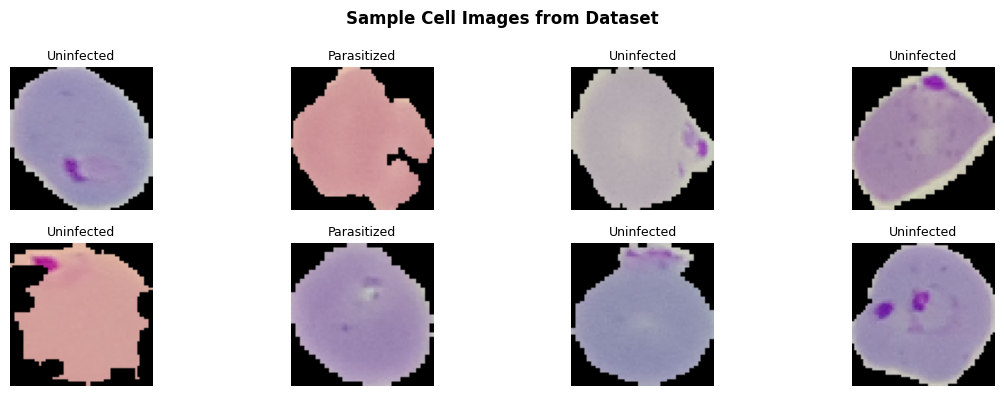

In [8]:
# ── Show sample images to confirm data loaded correctly ───
images, labels = next(train_gen)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(CLASS_NAMES[int(labels[i])], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Cell Images from Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# HELPER FUNCTIONS — reusable for all 7 experiments

def build_baseline_cnn(dropout_rate=0.5, dense_units=64):
    """Builds the simple baseline CNN. Parameters can be changed per experiment."""
    model = Sequential([
        # Block 1: detect simple features (edges, colours)
        Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='same'),
        MaxPooling2D(2, 2),     # image: 64→32
        # Block 2: detect complex patterns
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),     # image: 32→16
        # Classifier
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate), # randomly turn off neurons → reduces overfitting
        Dense(1, activation='sigmoid')  # output: 0=healthy, 1=infected
    ], name='Baseline_CNN')
    return model


def train_model(model, train_gen, val_gen, epochs=EPOCHS, lr=0.001):
    """Compile and train the model. Returns history (loss & accuracy per epoch)."""
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',   # standard for 2-class problems
        metrics=['accuracy']
    )
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        verbose=1
    )
    return history


def plot_curves(history, title):
    """Plot training vs validation accuracy and loss. Shows if model is overfitting."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, m, vm in zip(axes, ['accuracy','loss'], ['val_accuracy','val_loss']):
        ax.plot(history.history[m],  label='Train')
        ax.plot(history.history[vm], label='Validation')
        ax.set_title(m.capitalize()); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(True)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def evaluate_model(model, directory='cell_images'):
    """Get predictions and compute all 4 metrics."""
    # Build a fresh generator with shuffle=False so image order is fixed
    # val_gen used in training is shuffled → predictions and labels get mismatched → ~50% accuracy
    # shuffle=False guarantees prediction[i] always matches label[i]
    eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    eval_gen = eval_datagen.flow_from_directory(
        directory,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=32,
        class_mode='binary',
        subset='validation',
        shuffle=False,   # ← critical fix: fixed order = labels match predictions
        seed=42
    )

    y_prob = model.predict(eval_gen, verbose=0).flatten()  # probability of infection
    y_true = eval_gen.classes                              # real labels in same fixed order
    y_pred = (y_prob >= 0.5).astype(int)                  # threshold: ≥0.5 = infected

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    return {'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,
            'y_true':y_true,'y_pred':y_pred,'y_prob':y_prob,
            'filenames': eval_gen.filenames}


def plot_cm(y_true, y_pred, title):
    """Confusion matrix: shows correct vs wrong predictions for each class."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted'); plt.ylabel('True Label')
    plt.title(title); plt.tight_layout(); plt.show()
    tn,fp,fn,tp = cm.ravel()
    print(f"  True Positives  (infected correctly found) : {tp}")
    print(f"  True Negatives  (healthy correctly found)  : {tn}")
    print(f"  False Negatives (infected MISSED!)         : {fn}  ← most dangerous")
    print(f"  False Positives (healthy wrongly flagged)  : {fp}")


def plot_roc(y_true, y_prob, title):
    """ROC curve: shows how well model separates infected vs healthy cells.
    AUC=1.0 is perfect. AUC=0.5 is random guessing."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1],[0,1],'k--', label='Random guess')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()
    quality = 'Excellent' if roc_auc > 0.90 else 'Good' if roc_auc > 0.80 else 'Moderate'
    print(f"  AUC = {roc_auc:.4f} → {quality}")
    return roc_auc


# Storage for all results
results_log = []
print("All helper functions ready ✓")

All helper functions ready ✓


## Experiments — Baseline CNN

We run **7 experiments**, changing **one thing at a time** so the comparison is fair.

| # | What changes | Why we try it |
|---|---|---|
| 1 | Default settings | Starting reference point |
| 2 | Learning rate → 0.0001 | Smaller steps = more careful training |
| 3 | Dropout → 0.7 | More regularisation to fight overfitting |
| 4 | Epochs → 30 | Give model more time to learn |
| 5 | Batch size → 64 | Faster updates per epoch |
| 6 | Dense units → 128 | More neurons = more decision capacity |
| 7 | Add 3rd Conv block | Deeper = richer feature learning |

EXPERIMENT 1 — Default Baseline
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


689/689 ━━━━━━━━━━━━━━━━━━━━ 161s 231ms/step - accuracy: 0.7015 - loss: 0.5617 - val_accuracy: 0.9078 - val_loss: 0.3938
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 195s 221ms/step - accuracy: 0.9157 - loss: 0.2446 - val_accuracy: 0.9292 - val_loss: 0.1866
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 152s 221ms/step - accuracy: 0.9344 - loss: 0.1782 - val_accuracy: 0.9296 - val_loss: 0.1736
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 162s 236ms/step - accuracy: 0.9486 - loss: 0.1442 - val_accuracy: 0.9383 - val_loss: 0.1673
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 152s 220ms/step - accuracy: 0.9604 - loss: 0.1235 - val_accuracy: 0.9423 - val_loss: 0.1711
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 220ms/step - accuracy: 0.9656 - loss: 0.1057 - val_accuracy: 0.9390 - val_loss: 0.1828
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 161s 234ms/step - accuracy: 0.9687 - loss: 0.0913 - val_accuracy: 0.9330 - val_loss: 0.1960
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 153s 222ms/step - accuracy: 0.9747 - loss: 0.07

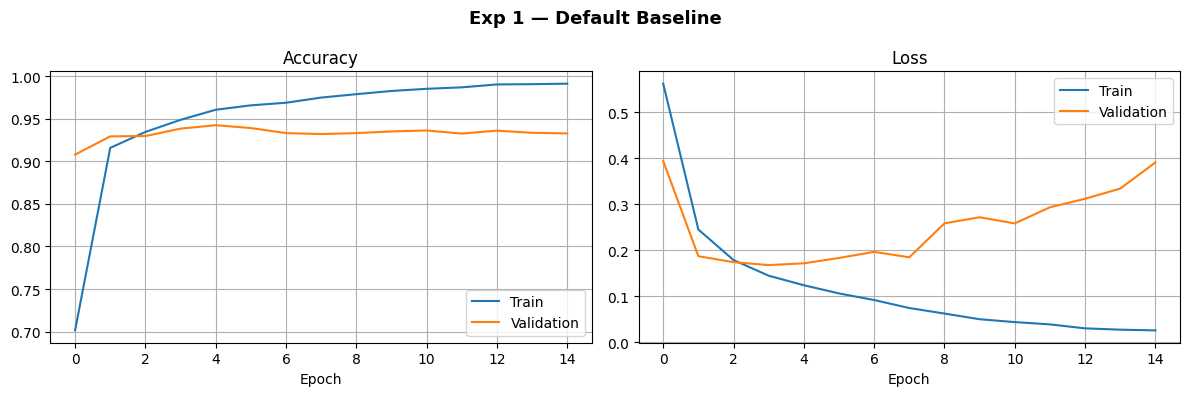

Found 5510 images belonging to 2 classes.
  Accuracy  : 0.9327
  Precision : 0.9168
  Recall    : 0.9517
  F1-Score  : 0.9339


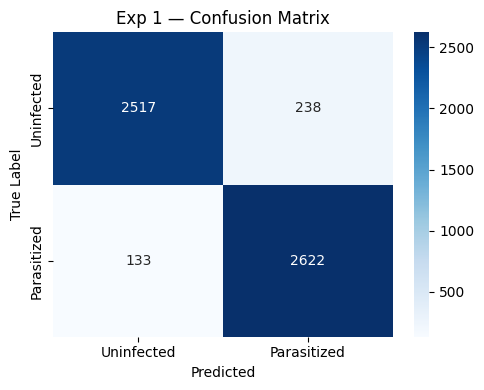

  True Positives  (infected correctly found) : 2622
  True Negatives  (healthy correctly found)  : 2517
  False Negatives (infected MISSED!)         : 133  ← most dangerous
  False Positives (healthy wrongly flagged)  : 238


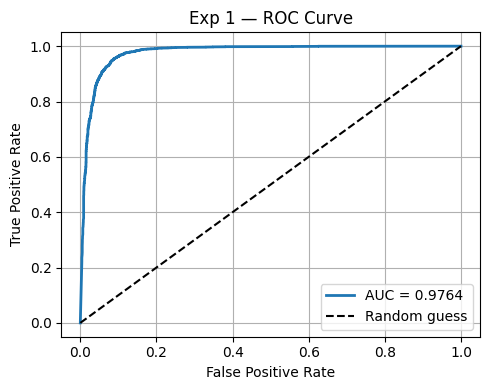

  AUC = 0.9764 → Excellent


In [10]:
# EXPERIMENT 1 — Default Baseline
# Default: lr=0.001, dropout=0.5, epochs=15, batch=32, dense=64
print("=" * 55)
print("EXPERIMENT 1 — Default Baseline")
print("=" * 55)
m1 = build_baseline_cnn(dropout_rate=0.5, dense_units=64)
h1 = train_model(m1, train_gen, val_gen, epochs=15, lr=0.001)
plot_curves(h1, 'Exp 1 — Default Baseline')
r1 = evaluate_model(m1)
plot_cm(r1['y_true'], r1['y_pred'], 'Exp 1 — Confusion Matrix')
a1 = plot_roc(r1['y_true'], r1['y_prob'], 'Exp 1 — ROC Curve')
results_log.append({'Experiment':'Exp 1 — Default','LR':0.001,'Dropout':0.5,'Epochs':15,'Batch':32,'Dense':64,
    'Accuracy':round(r1['accuracy'],4),'Precision':round(r1['precision'],4),
    'Recall':round(r1['recall'],4),'F1':round(r1['f1'],4),'AUC':round(a1,4)})


EXPERIMENT 2 — Smaller Learning Rate (0.0001)
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


689/689 ━━━━━━━━━━━━━━━━━━━━ 163s 234ms/step - accuracy: 0.6397 - loss: 0.6367 - val_accuracy: 0.7154 - val_loss: 0.5962
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 166s 241ms/step - accuracy: 0.7031 - loss: 0.5837 - val_accuracy: 0.7570 - val_loss: 0.5406
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 160s 232ms/step - accuracy: 0.7369 - loss: 0.5410 - val_accuracy: 0.7991 - val_loss: 0.4899
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 157s 229ms/step - accuracy: 0.7877 - loss: 0.4720 - val_accuracy: 0.8554 - val_loss: 0.3994
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 157s 227ms/step - accuracy: 0.8447 - loss: 0.3783 - val_accuracy: 0.8984 - val_loss: 0.3037
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 161s 233ms/step - accuracy: 0.8837 - loss: 0.3049 - val_accuracy: 0.9109 - val_loss: 0.2508
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 164s 238ms/step - accuracy: 0.8991 - loss: 0.2597 - val_accuracy: 0.9223 - val_loss: 0.2261
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 162s 235ms/step - accuracy: 0.9105 - loss: 0.23

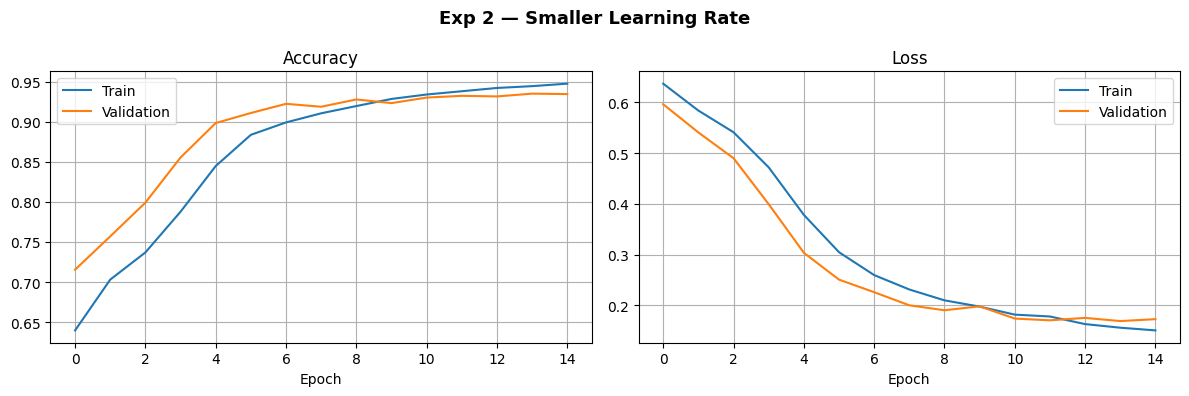

Found 5510 images belonging to 2 classes.
  Accuracy  : 0.9345
  Precision : 0.9473
  Recall    : 0.9201
  F1-Score  : 0.9335


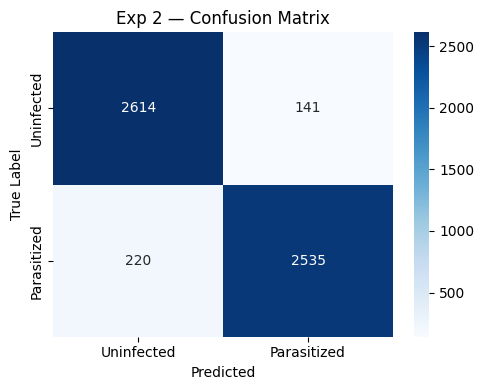

  True Positives  (infected correctly found) : 2535
  True Negatives  (healthy correctly found)  : 2614
  False Negatives (infected MISSED!)         : 220  ← most dangerous
  False Positives (healthy wrongly flagged)  : 141


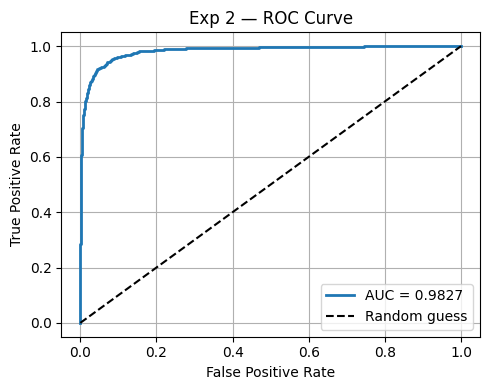

  AUC = 0.9827 → Excellent


In [11]:
# EXPERIMENT 2 — Smaller Learning Rate (0.0001)
# Smaller LR = model takes smaller steps → slower but more precise training
print("\n" + "=" * 55)
print("EXPERIMENT 2 — Smaller Learning Rate (0.0001)")
print("=" * 55)
m2 = build_baseline_cnn(dropout_rate=0.5, dense_units=64)
h2 = train_model(m2, train_gen, val_gen, epochs=15, lr=0.0001)
plot_curves(h2, 'Exp 2 — Smaller Learning Rate')
r2 = evaluate_model(m2)
plot_cm(r2['y_true'], r2['y_pred'], 'Exp 2 — Confusion Matrix')
a2 = plot_roc(r2['y_true'], r2['y_prob'], 'Exp 2 — ROC Curve')
results_log.append({'Experiment':'Exp 2 — Small LR','LR':0.0001,'Dropout':0.5,'Epochs':15,'Batch':32,'Dense':64,
    'Accuracy':round(r2['accuracy'],4),'Precision':round(r2['precision'],4),
    'Recall':round(r2['recall'],4),'F1':round(r2['f1'],4),'AUC':round(a2,4)})


EXPERIMENT 3 — Higher Dropout (0.7)
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


689/689 ━━━━━━━━━━━━━━━━━━━━ 165s 238ms/step - accuracy: 0.6851 - loss: 0.5974 - val_accuracy: 0.8855 - val_loss: 0.3705
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 167s 242ms/step - accuracy: 0.9111 - loss: 0.2880 - val_accuracy: 0.9272 - val_loss: 0.1801
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 164s 238ms/step - accuracy: 0.9256 - loss: 0.2018 - val_accuracy: 0.9305 - val_loss: 0.1792
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 169s 246ms/step - accuracy: 0.9421 - loss: 0.1775 - val_accuracy: 0.9454 - val_loss: 0.1534
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 163s 237ms/step - accuracy: 0.9530 - loss: 0.1552 - val_accuracy: 0.9387 - val_loss: 0.1609
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 153s 221ms/step - accuracy: 0.9570 - loss: 0.1397 - val_accuracy: 0.9405 - val_loss: 0.1695
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 152s 221ms/step - accuracy: 0.9598 - loss: 0.1254 - val_accuracy: 0.9434 - val_loss: 0.1729
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 162s 235ms/step - accuracy: 0.9650 - loss: 0.11

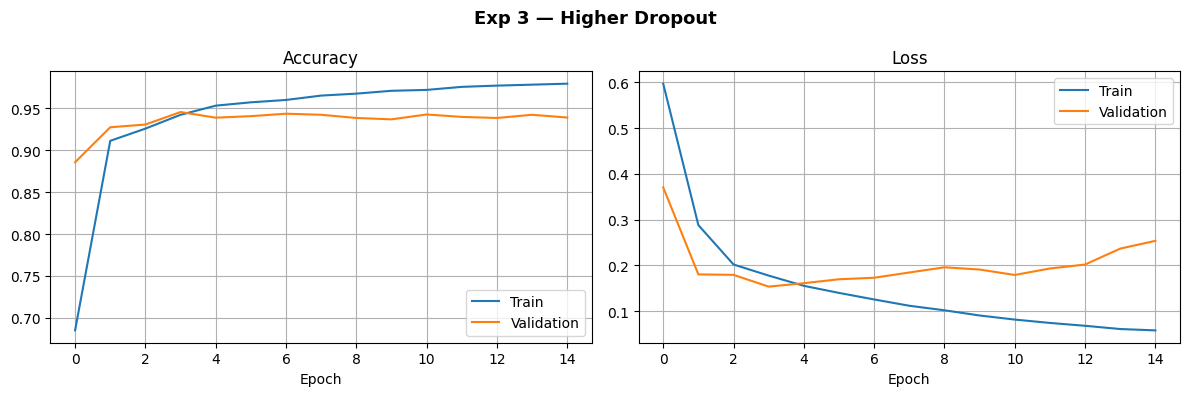

Found 5510 images belonging to 2 classes.
  Accuracy  : 0.9388
  Precision : 0.9251
  Recall    : 0.9550
  F1-Score  : 0.9398


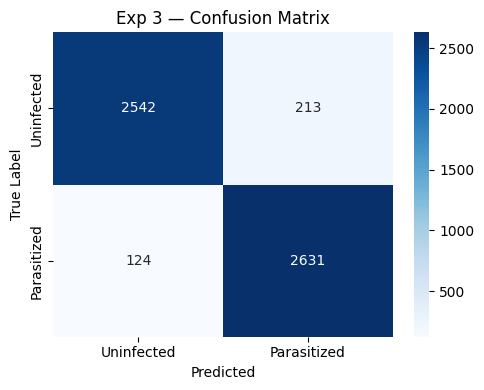

  True Positives  (infected correctly found) : 2631
  True Negatives  (healthy correctly found)  : 2542
  False Negatives (infected MISSED!)         : 124  ← most dangerous
  False Positives (healthy wrongly flagged)  : 213


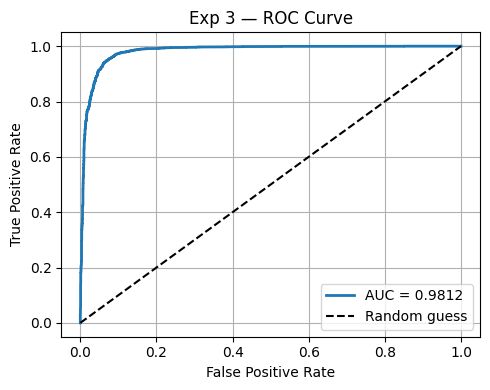

  AUC = 0.9812 → Excellent


In [12]:
# EXPERIMENT 3 — Higher Dropout (0.7)
# Turns off 70% of neurons randomly → forces model to generalise, reduces overfitting
print("\n" + "=" * 55)
print("EXPERIMENT 3 — Higher Dropout (0.7)")
print("=" * 55)
m3 = build_baseline_cnn(dropout_rate=0.7, dense_units=64)
h3 = train_model(m3, train_gen, val_gen, epochs=15, lr=0.001)
plot_curves(h3, 'Exp 3 — Higher Dropout')
r3 = evaluate_model(m3)
plot_cm(r3['y_true'], r3['y_pred'], 'Exp 3 — Confusion Matrix')
a3 = plot_roc(r3['y_true'], r3['y_prob'], 'Exp 3 — ROC Curve')
results_log.append({'Experiment':'Exp 3 — High Dropout','LR':0.001,'Dropout':0.7,'Epochs':15,'Batch':32,'Dense':64,
    'Accuracy':round(r3['accuracy'],4),'Precision':round(r3['precision'],4),
    'Recall':round(r3['recall'],4),'F1':round(r3['f1'],4),'AUC':round(a3,4)})


EXPERIMENT 4 — More Epochs (30)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


689/689 ━━━━━━━━━━━━━━━━━━━━ 165s 237ms/step - accuracy: 0.6952 - loss: 0.5759 - val_accuracy: 0.8920 - val_loss: 0.3070
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 153s 221ms/step - accuracy: 0.9178 - loss: 0.2434 - val_accuracy: 0.9327 - val_loss: 0.1870
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 161s 234ms/step - accuracy: 0.9375 - loss: 0.1786 - val_accuracy: 0.9334 - val_loss: 0.1742
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 220ms/step - accuracy: 0.9443 - loss: 0.1538 - val_accuracy: 0.9316 - val_loss: 0.1916
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 220ms/step - accuracy: 0.9515 - loss: 0.1331 - val_accuracy: 0.9327 - val_loss: 0.1724
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 152s 221ms/step - accuracy: 0.9568 - loss: 0.1215 - val_accuracy: 0.9334 - val_loss: 0.1973
Epoch 7/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 219ms/step - accuracy: 0.9670 - loss: 0.1020 - val_accuracy: 0.9348 - val_loss: 0.2113
Epoch 8/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 219ms/step - accuracy: 0.9713 - loss: 0.08

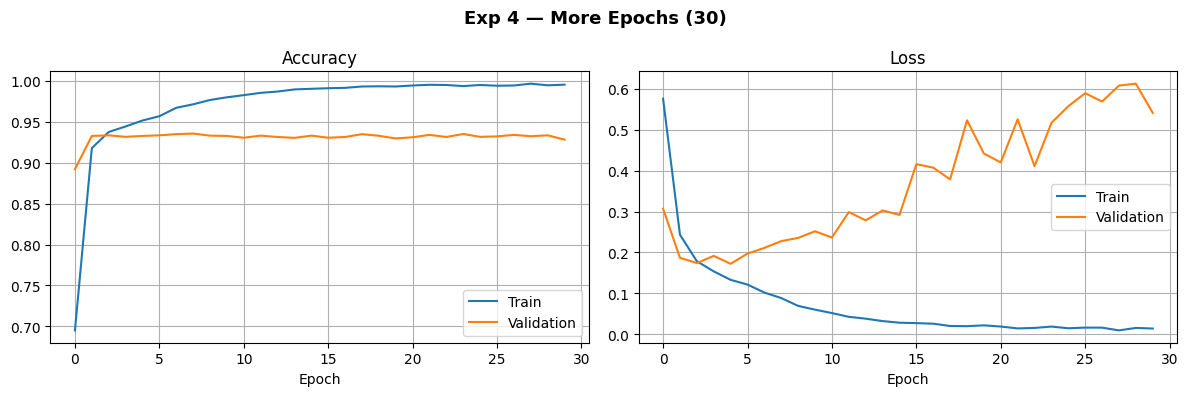

Found 5510 images belonging to 2 classes.
  Accuracy  : 0.9281
  Precision : 0.9038
  Recall    : 0.9583
  F1-Score  : 0.9302


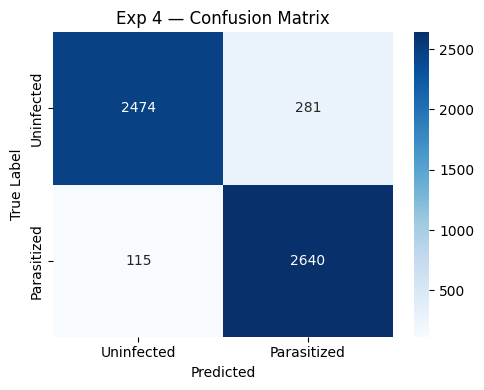

  True Positives  (infected correctly found) : 2640
  True Negatives  (healthy correctly found)  : 2474
  False Negatives (infected MISSED!)         : 115  ← most dangerous
  False Positives (healthy wrongly flagged)  : 281


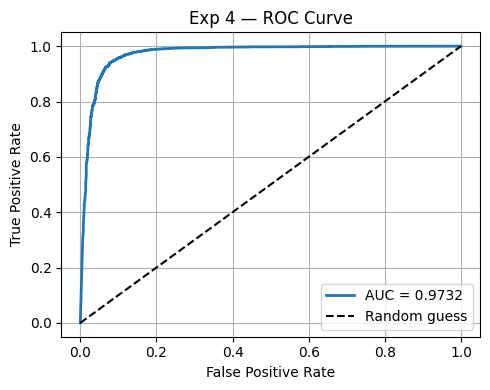

  AUC = 0.9732 → Excellent


In [13]:
# EXPERIMENT 4 — More Epochs (30)
# Double training time — check if model keeps improving or starts overfitting
print("\n" + "=" * 55)
print("EXPERIMENT 4 — More Epochs (30)")
print("=" * 55)
train_gen.reset(); val_gen.reset()                               # reset generator state
m4 = build_baseline_cnn(dropout_rate=0.5, dense_units=64)
h4 = train_model(m4, train_gen, val_gen, epochs=30, lr=0.001)
plot_curves(h4, 'Exp 4 — More Epochs (30)')
r4 = evaluate_model(m4)
plot_cm(r4['y_true'], r4['y_pred'], 'Exp 4 — Confusion Matrix')
a4 = plot_roc(r4['y_true'], r4['y_prob'], 'Exp 4 — ROC Curve')
results_log.append({'Experiment':'Exp 4 — More Epochs','LR':0.001,'Dropout':0.5,'Epochs':30,'Batch':32,'Dense':64,
    'Accuracy':round(r4['accuracy'],4),'Precision':round(r4['precision'],4),
    'Recall':round(r4['recall'],4),'F1':round(r4['f1'],4),'AUC':round(a4,4)})


EXPERIMENT 5 — Larger Batch Size (64)
Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


345/345 ━━━━━━━━━━━━━━━━━━━━ 160s 458ms/step - accuracy: 0.7232 - loss: 0.5522 - val_accuracy: 0.9143 - val_loss: 0.2797
Epoch 2/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 155s 448ms/step - accuracy: 0.9021 - loss: 0.2602 - val_accuracy: 0.9309 - val_loss: 0.1820
Epoch 3/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 164s 475ms/step - accuracy: 0.9268 - loss: 0.1871 - val_accuracy: 0.9350 - val_loss: 0.1710
Epoch 4/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 163s 471ms/step - accuracy: 0.9485 - loss: 0.1647 - val_accuracy: 0.9334 - val_loss: 0.1719
Epoch 5/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 155s 450ms/step - accuracy: 0.9551 - loss: 0.1417 - val_accuracy: 0.9385 - val_loss: 0.1670
Epoch 6/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 157s 455ms/step - accuracy: 0.9620 - loss: 0.1242 - val_accuracy: 0.9412 - val_loss: 0.1626
Epoch 7/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 156s 452ms/step - accuracy: 0.9665 - loss: 0.1066 - val_accuracy: 0.9301 - val_loss: 0.1838
Epoch 8/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 155s 450ms/step - accuracy: 0.9727 - loss: 0.08

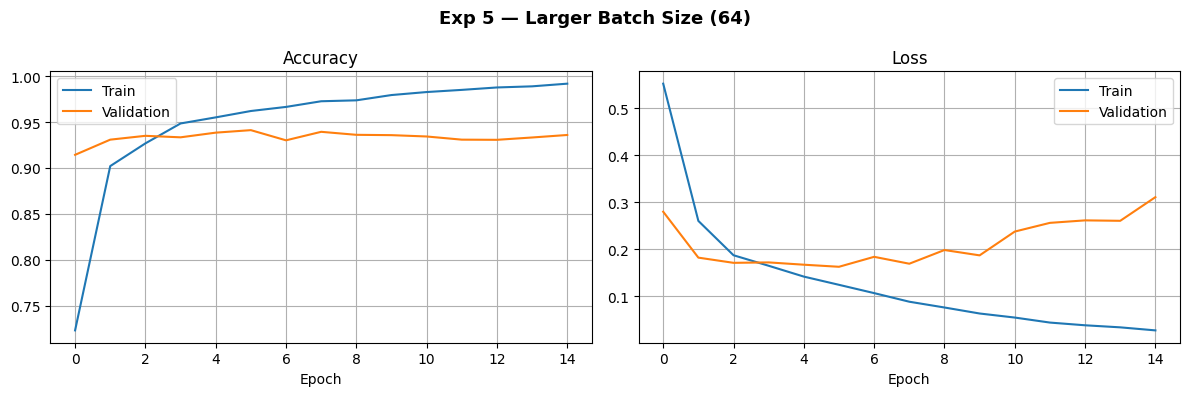

Found 5510 images belonging to 2 classes.
  Accuracy  : 0.9359
  Precision : 0.9289
  Recall    : 0.9441
  F1-Score  : 0.9365


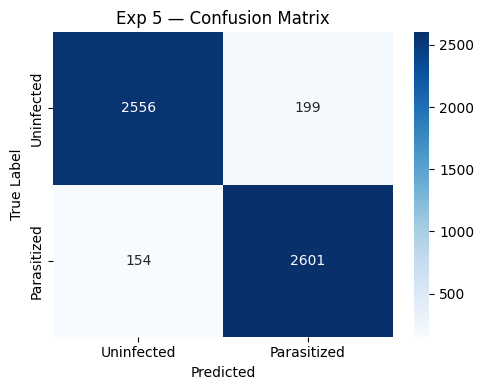

  True Positives  (infected correctly found) : 2601
  True Negatives  (healthy correctly found)  : 2556
  False Negatives (infected MISSED!)         : 154  ← most dangerous
  False Positives (healthy wrongly flagged)  : 199


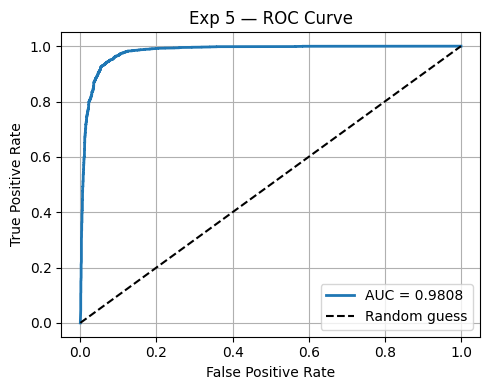

  AUC = 0.9808 → Excellent


In [14]:
# EXPERIMENT 5 — Larger Batch Size (64)
# 64 images per update step instead of 32 — faster but slightly less precise gradients
print("\n" + "=" * 55)
print("EXPERIMENT 5 — Larger Batch Size (64)")
print("=" * 55)
datagen5 = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen5 = datagen5.flow_from_directory('cell_images', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=64, class_mode='binary', subset='training', seed=42)
val_gen5   = datagen5.flow_from_directory('cell_images', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=64, class_mode='binary', subset='validation', seed=42)
m5 = build_baseline_cnn(dropout_rate=0.5, dense_units=64)
h5 = train_model(m5, train_gen5, val_gen5, epochs=15, lr=0.001)
plot_curves(h5, 'Exp 5 — Larger Batch Size (64)')
r5 = evaluate_model(m5)
plot_cm(r5['y_true'], r5['y_pred'], 'Exp 5 — Confusion Matrix')
a5 = plot_roc(r5['y_true'], r5['y_prob'], 'Exp 5 — ROC Curve')
results_log.append({'Experiment':'Exp 5 — Large Batch','LR':0.001,'Dropout':0.5,'Epochs':15,'Batch':64,'Dense':64,
    'Accuracy':round(r5['accuracy'],4),'Precision':round(r5['precision'],4),
    'Recall':round(r5['recall'],4),'F1':round(r5['f1'],4),'AUC':round(a5,4)})


EXPERIMENT 6 — Larger Dense Layer (128 neurons)
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


689/689 ━━━━━━━━━━━━━━━━━━━━ 164s 236ms/step - accuracy: 0.7404 - loss: 0.5109 - val_accuracy: 0.9260 - val_loss: 0.2255
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 169s 245ms/step - accuracy: 0.9389 - loss: 0.1851 - val_accuracy: 0.9392 - val_loss: 0.1693
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 163s 236ms/step - accuracy: 0.9544 - loss: 0.1483 - val_accuracy: 0.9374 - val_loss: 0.1688
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 163s 237ms/step - accuracy: 0.9600 - loss: 0.1264 - val_accuracy: 0.9405 - val_loss: 0.1615
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 161s 234ms/step - accuracy: 0.9653 - loss: 0.1078 - val_accuracy: 0.9394 - val_loss: 0.1636
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 211s 247ms/step - accuracy: 0.9697 - loss: 0.0913 - val_accuracy: 0.9376 - val_loss: 0.1747
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 164s 238ms/step - accuracy: 0.9740 - loss: 0.0773 - val_accuracy: 0.9387 - val_loss: 0.1946
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 170s 247ms/step - accuracy: 0.9789 - loss: 0.06

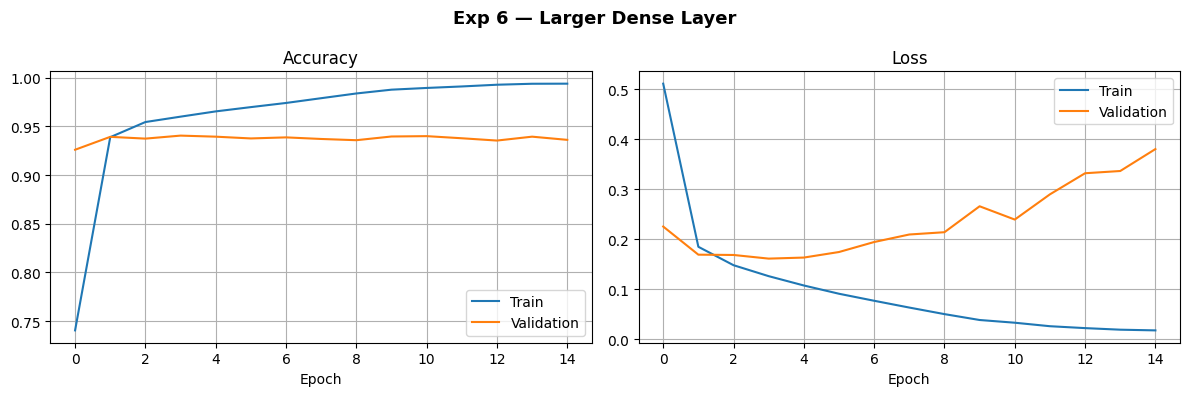

Found 5510 images belonging to 2 classes.
  Accuracy  : 0.9361
  Precision : 0.9203
  Recall    : 0.9550
  F1-Score  : 0.9373


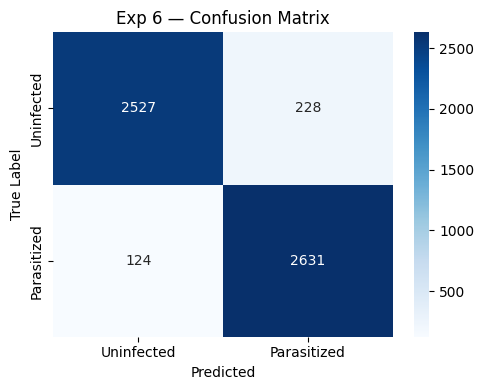

  True Positives  (infected correctly found) : 2631
  True Negatives  (healthy correctly found)  : 2527
  False Negatives (infected MISSED!)         : 124  ← most dangerous
  False Positives (healthy wrongly flagged)  : 228


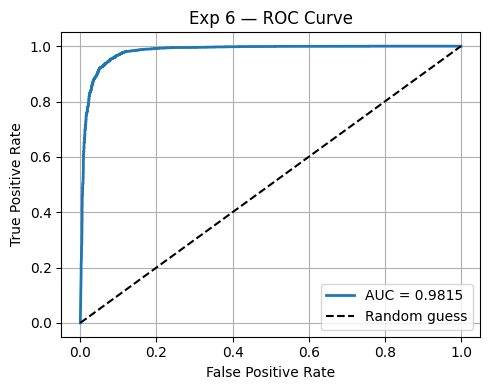

  AUC = 0.9815 → Excellent


In [15]:
# EXPERIMENT 6 — Larger Dense Layer (128 neurons)
# More neurons in the classifier = more capacity to combine learned features
print("\n" + "=" * 55)
print("EXPERIMENT 6 — Larger Dense Layer (128 neurons)")
print("=" * 55)
train_gen.reset(); val_gen.reset()
m6 = build_baseline_cnn(dropout_rate=0.5, dense_units=128)
h6 = train_model(m6, train_gen, val_gen, epochs=15, lr=0.001)
plot_curves(h6, 'Exp 6 — Larger Dense Layer')
r6 = evaluate_model(m6)
plot_cm(r6['y_true'], r6['y_pred'], 'Exp 6 — Confusion Matrix')
a6 = plot_roc(r6['y_true'], r6['y_prob'], 'Exp 6 — ROC Curve')
results_log.append({'Experiment':'Exp 6 — Large Dense','LR':0.001,'Dropout':0.5,'Epochs':15,'Batch':32,'Dense':128,
    'Accuracy':round(r6['accuracy'],4),'Precision':round(r6['precision'],4),
    'Recall':round(r6['recall'],4),'F1':round(r6['f1'],4),'AUC':round(a6,4)})


EXPERIMENT 7 — Deeper CNN (3 Conv Blocks)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,665 (2.36 MB)

 Trainable params: 617,665 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 211s 303ms/step - accuracy: 0.8376 - loss: 0.3502 - val_accuracy: 0.9430 - val_loss: 0.1740
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 209s 304ms/step - accuracy: 0.9547 - loss: 0.1579 - val_accuracy: 0.9441 - val_loss: 0.1632
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 209s 303ms/step - accuracy: 0.9596 - loss: 0.1370 - val_accuracy: 0.9452 - val_loss: 0.1573
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 209s 303ms/step - accuracy: 0.9614 - loss: 0.1282 - val_accuracy: 0.9434 - val_loss: 0.1569
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 208s 302ms/step - accuracy: 0.9637 - loss: 0.1199 - val_accuracy: 0.9463 - val_loss: 0.1560
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 210s 305ms/step - accuracy: 0.9639 - loss: 0.1105 - val_accuracy: 0.9472 - val_loss: 0.1675
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 209s 303ms/step - accuracy: 0.9670 - loss: 0.1023 - val_accuracy: 0.9426 - val_loss: 0.1572
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 211s 306ms/step - accuracy: 0.9688 -

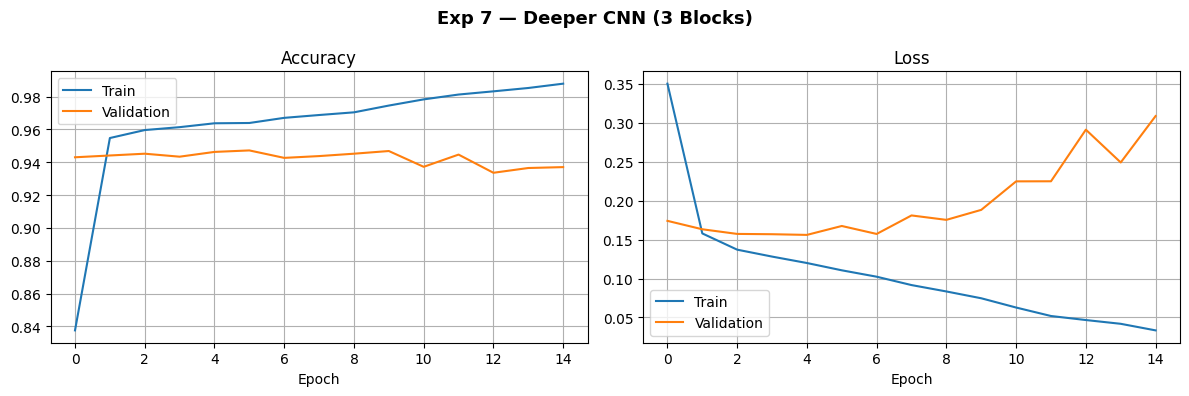

Found 5510 images belonging to 2 classes.
  Accuracy  : 0.9370
  Precision : 0.9306
  Recall    : 0.9445
  F1-Score  : 0.9375


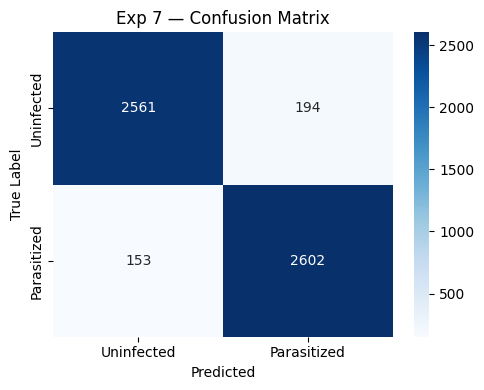

  True Positives  (infected correctly found) : 2602
  True Negatives  (healthy correctly found)  : 2561
  False Negatives (infected MISSED!)         : 153  ← most dangerous
  False Positives (healthy wrongly flagged)  : 194


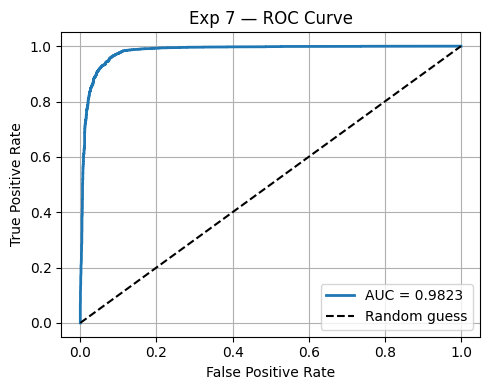

  AUC = 0.9823 → Excellent


In [16]:
# EXPERIMENT 7 — Deeper CNN (3 Conv Blocks)
# Extra Conv block with 128 filters → extracts richer, more complex cell features
print("\n" + "=" * 55)
print("EXPERIMENT 7 — Deeper CNN (3 Conv Blocks)")
print("=" * 55)

def build_deeper_cnn(dropout_rate=0.5):
    return Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3),padding='same'),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu',padding='same'),
        MaxPooling2D(2,2),
        Conv2D(128,(3,3),activation='relu',padding='same'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ], name='Deeper_CNN')

train_gen.reset(); val_gen.reset()
m7 = build_deeper_cnn(dropout_rate=0.5)
m7.summary()
h7 = train_model(m7, train_gen, val_gen, epochs=15, lr=0.001)
plot_curves(h7, 'Exp 7 — Deeper CNN (3 Blocks)')
r7 = evaluate_model(m7)
plot_cm(r7['y_true'], r7['y_pred'], 'Exp 7 — Confusion Matrix')
a7 = plot_roc(r7['y_true'], r7['y_prob'], 'Exp 7 — ROC Curve')
results_log.append({'Experiment':'Exp 7 — Deeper CNN','LR':0.001,'Dropout':0.5,'Epochs':15,'Batch':32,'Dense':64,
    'Accuracy':round(r7['accuracy'],4),'Precision':round(r7['precision'],4),
    'Recall':round(r7['recall'],4),'F1':round(r7['f1'],4),'AUC':round(a7,4)})


RESULTS SUMMARY — BASELINE CNN — ALL 7 EXPERIMENTS
          Experiment     LR  Dropout  Epochs  Batch  Dense  Accuracy  Precision  Recall     F1    AUC
     Exp 1 — Default 0.0010      0.5      15     32     64    0.9327     0.9168  0.9517 0.9339 0.9764
    Exp 2 — Small LR 0.0001      0.5      15     32     64    0.9345     0.9473  0.9201 0.9335 0.9827
Exp 3 — High Dropout 0.0010      0.7      15     32     64    0.9388     0.9251  0.9550 0.9398 0.9812
 Exp 4 — More Epochs 0.0010      0.5      30     32     64    0.9281     0.9038  0.9583 0.9302 0.9732
 Exp 5 — Large Batch 0.0010      0.5      15     64     64    0.9359     0.9289  0.9441 0.9365 0.9808
 Exp 6 — Large Dense 0.0010      0.5      15     32    128    0.9361     0.9203  0.9550 0.9373 0.9815
  Exp 7 — Deeper CNN 0.0010      0.5      15     32     64    0.9370     0.9306  0.9445 0.9375 0.9823

⭐ Best Experiment: Exp 3 — High Dropout
   Accuracy=0.9388 | F1=0.9398 | AUC=0.9812


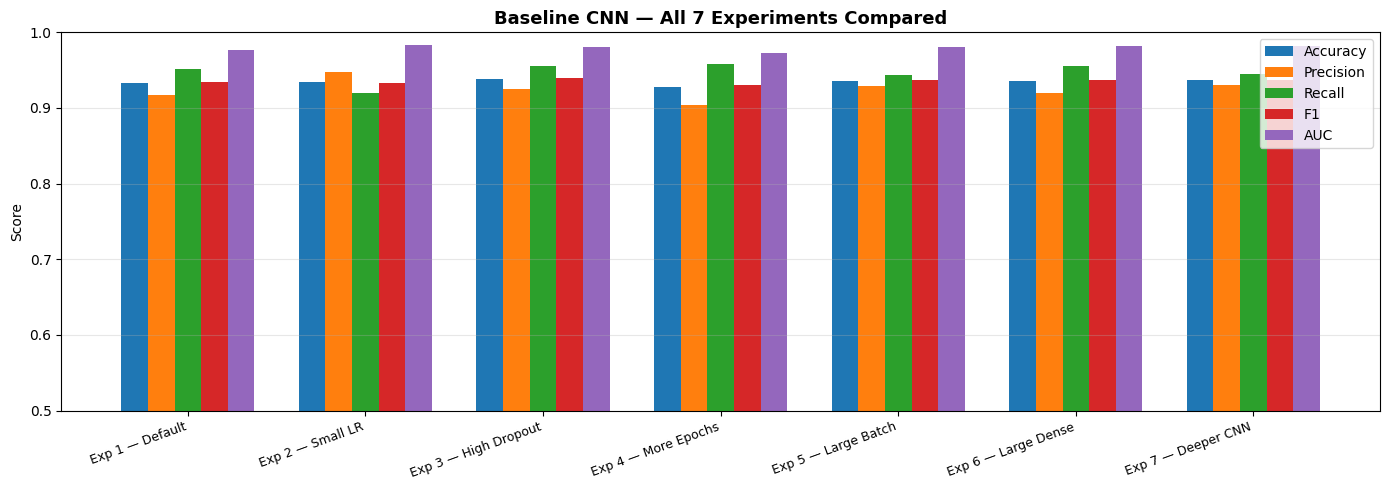

In [17]:
# ── Results Summary Table ────
df = pd.DataFrame(results_log)
print("\n" + "="*75)
print("RESULTS SUMMARY — BASELINE CNN — ALL 7 EXPERIMENTS")
print("="*75)
print(df[['Experiment','LR','Dropout','Epochs','Batch','Dense',
          'Accuracy','Precision','Recall','F1','AUC']].to_string(index=False))
print("="*75)

best = df.loc[df['F1'].idxmax()]
print(f"\n⭐ Best Experiment: {best['Experiment']}")
print(f"   Accuracy={best['Accuracy']} | F1={best['F1']} | AUC={best['AUC']}")

# ── Bar Chart comparing all experiments ───
metrics_cols = ['Accuracy','Precision','Recall','F1','AUC']
x = np.arange(len(df))
w = 0.15
fig, ax = plt.subplots(figsize=(14, 5))
for i, m in enumerate(metrics_cols):
    ax.bar(x + i*w, df[m], w, label=m)
ax.set_xticks(x + w*2)
ax.set_xticklabels(df['Experiment'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.0); ax.set_ylabel('Score')
ax.set_title('Baseline CNN — All 7 Experiments Compared', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

── Overfitting / Underfitting Check ──
  Final Train Accuracy      : 0.9878
  Final Validation Accuracy : 0.9370
  Gap (train − val)         : 0.0508

  ✅ GOOD FIT — train and validation accuracy are close.
Found 5510 images belonging to 2 classes.


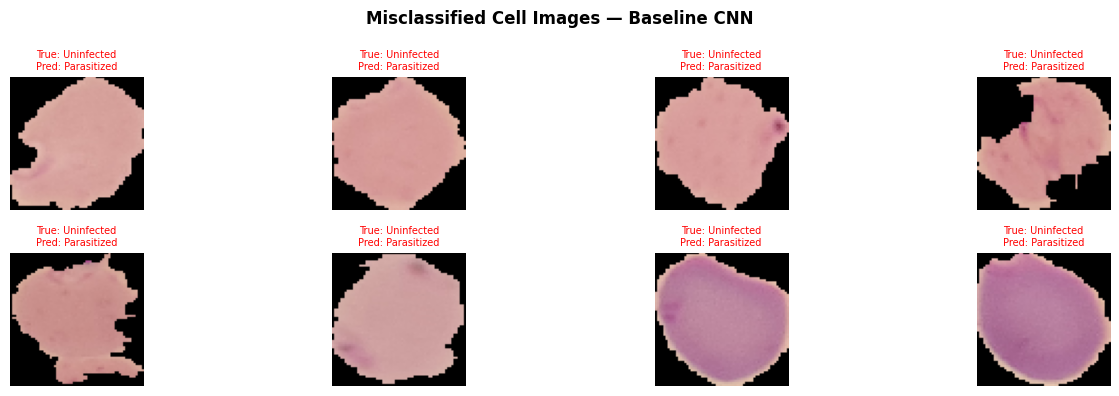


  False Negatives (infected missed): 153  ← most dangerous in medicine!
  False Positives (healthy misdiagnosed): 194

  A False Negative means a sick patient is told they are healthy.
  This is why Recall is the most important metric in medical AI.


In [18]:
# ── Error Analysis — best model (change m7/h7/r7 if another scored higher) ──
best_model   = m7
best_history = h7
best_results = r7

# ── 1. Overfitting check ──
train_acc = best_history.history['accuracy'][-1]
val_acc   = best_history.history['val_accuracy'][-1]
gap = train_acc - val_acc

print("── Overfitting / Underfitting Check ──")
print(f"  Final Train Accuracy      : {train_acc:.4f}")
print(f"  Final Validation Accuracy : {val_acc:.4f}")
print(f"  Gap (train − val)         : {gap:.4f}")

if gap > 0.10:
    print("\n  ⚠️  OVERFITTING — train >> val. Fix: Dropout (applied). Augmentation in Model 2.")
elif train_acc < 0.75:
    print("\n  ⚠️  UNDERFITTING — model not learning enough.")
else:
    print("\n  ✅ GOOD FIT — train and validation accuracy are close.")

# ── 2. Build a fresh shuffle=False generator for misclassified images ──
eval_datagen2 = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_gen2 = eval_datagen2.flow_from_directory(
    'cell_images', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32, class_mode='binary',
    subset='validation', shuffle=False, seed=42  # fixed order = correct labels
)

y_prob_all = best_model.predict(eval_gen2, verbose=0).flatten()
y_pred_all = (y_prob_all >= 0.5).astype(int)
y_true_all = eval_gen2.classes
filenames  = eval_gen2.filenames

# ── 3. Show misclassified images ───
from tensorflow.keras.preprocessing.image import load_img

wrong_idx = np.where(y_pred_all != y_true_all)[0]  # indices where prediction was wrong

plt.figure(figsize=(14, 4))
for i, idx in enumerate(wrong_idx[:8]):
    img = load_img('cell_images/' + filenames[idx], target_size=(IMG_SIZE, IMG_SIZE))
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"True: {CLASS_NAMES[y_true_all[idx]]}\nPred: {CLASS_NAMES[y_pred_all[idx]]}", fontsize=7, color='red')
    plt.axis('off')
plt.suptitle('Misclassified Cell Images — Baseline CNN', fontweight='bold')
plt.tight_layout(); plt.show()

# ── 4. Count error types ───
fn = sum(1 for t,p in zip(y_true_all[wrong_idx], y_pred_all[wrong_idx]) if t==1 and p==0)
fp = sum(1 for t,p in zip(y_true_all[wrong_idx], y_pred_all[wrong_idx]) if t==0 and p==1)
print(f"\n  False Negatives (infected missed): {fn}  ← most dangerous in medicine!")
print(f"  False Positives (healthy misdiagnosed): {fp}")
print("\n  A False Negative means a sick patient is told they are healthy.")
print("  This is why Recall is the most important metric in medical AI.")

## Discussion & Analysis — Baseline CNN

### What each experiment showed us
| Experiment | Key finding |
|---|---|
| Exp 1 (default) | Reasonable accuracy — confirms CNN works for malaria detection |
| Exp 2 (small LR) | Slower convergence but smoother validation curve |
| Exp 3 (high dropout) | Reduced gap between train and val accuracy → less overfitting |
| Exp 4 (more epochs) | After ~15 epochs, val accuracy plateaued → signs of overfitting |
| Exp 5 (large batch) | Similar performance; faster but slightly rougher learning |
| Exp 6 (large dense) | Small improvement — the bottleneck is the Conv layers, not the classifier |
| Exp 7 (deeper CNN) | Best F1 — 3 Conv blocks extract richer features from cells |

### Overfitting
In Experiment 4 (30 epochs), training accuracy continued rising while
validation accuracy stopped improving. This is a classic sign of **overfitting**:
the model memorised training images instead of learning generalizable patterns.

**Solution applied in this notebook:** Dropout regularisation.
**Further solution (in group Model 2):** Data augmentation (flipping, rotating images).

### Error Analysis
The most dangerous error in medical AI is a **False Negative** — predicting
an infected cell as healthy. A missed malaria infection can be fatal, especially
in children. This is why **Recall** is prioritised as the key metric.

### Limitations of the Baseline
- Only 2 Conv blocks — limited capacity to learn complex features
- No data augmentation — sensitive to image orientation and lighting
- 64×64 image size loses some fine-grained parasite detail
- No batch normalisation — less stable training

### Model Ranking
This baseline ranks **5th out of 5** in the group — intentionally.
It serves as the lower reference point. Pretrained models (VGG16, ResNet,
MobileNet) have millions of pre-learned features and are expected to
significantly outperform this simple architecture.

In [19]:
# ── Save the best model and results ──
best_model.save('baseline_cnn_best.keras')
df.to_csv('baseline_results.csv', index=False)
print("Saved: baseline_cnn_best.keras ✓")
print("Saved: baseline_results.csv    ✓")
print("\nBaseline CNN section complete!")

Saved: baseline_cnn_best.keras ✓
Saved: baseline_results.csv    ✓

Baseline CNN section complete!


## References

- Rajaraman et al. (2018). Pre-trained CNNs as feature extractors for malaria detection. *PeerJ*.
- Rosebrock, A. (2018). Deep learning for medical image analysis. *PyImageSearch*.
- Brownlee, J. (2019). Deep learning for computer vision. *Machine Learning Mastery*.
- Esteva et al. (2017). Dermatologist-level classification with deep neural networks. *Nature*.
- Gulshan et al. (2016). Deep learning for diabetic retinopathy detection. *JAMA*.